# Imports

In [1]:
import os
import sys

In [2]:
current_dir =  os.getcwd()
# replace this following line in the path your frank2d files are.
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
sys.path.append(parent_dir)

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import time

In [4]:
# frank2d
from frank2d import *

# frank1d
from frank.utilities import UVDataBinner

## Functions

In [5]:
def calculate_resolution( clean_beam, current_beam):
    bmaj_as = clean_beam['bmaj']
    bmin_as = clean_beam['bmin']
    final_bmaj_as = np.sqrt(bmaj_as**2 - current_beam**2)
    final_bmin_as = np.sqrt(bmin_as**2 - current_beam**2)
    print(f"-> Final beam to convolve with: {final_bmaj_as} x {final_bmin_as} arcsec")
    final_resolution = {'bmaj': final_bmaj_as, 'bmin': final_bmin_as, 'beam_pa': clean_beam['beam_pa']}
    return final_resolution

In [6]:
def calculate_resolution2( clean_beam, current_beam):
    from radio_beam import Beam
    bmaj_clean = clean_beam['bmaj']
    bmin_clean = clean_beam['bmin']
    bpa_deg_clean = clean_beam['beam_pa']

    bmaj_current = current_beam['bmaj']
    bmin_current = current_beam['bmin']
    bpa_deg_current = current_beam['beam_pa']

    beam_orig =  Beam(major=bmaj_current*u.arcsec, minor=bmin_current*u.arcsec, pa=bpa_deg_current)
    beam_target = Beam(major=bmaj_clean*u.arcsec, minor=bmin_clean*u.arcsec, pa=bpa_deg_clean)

    beam_final = beam_target.deconvolve(beam_orig)

    #return values in a dict
    final_resolution = {'bmaj': beam_final.major.to(u.arcsec).value,
                        'bmin': beam_final.minor.to(u.arcsec).value,
                        'beam_pa': beam_final.pa.to(u.deg).value}

    return final_resolution


In [7]:
def edges(x):
    mids = (x[1:] + x[:-1]) / 2.0
    first = x[0]  - (x[1] - x[0]) / 2.0
    last  = x[-1] + (x[-1] - x[-2]) / 2.0
    return np.r_[first, mids, last]


In [8]:
def get_profile( x1, x2, f, bins, weighted = False, weights = None, fit_1d = False):
    from scipy.stats import binned_statistic
    
    if not fit_1d:
        r = np.hypot(x1, x2)
        r = r.ravel(order = 'C')
        f = f.ravel(order = 'C')
    else:
        r = x1

    if weighted:
        if weights is None:
            raise ValueError("Add weights.")
        F_W_binned, bin_edges, _ = binned_statistic(r, f*weights, 'sum', bins = bins)
        Weights_binned, bin_edges, _ = binned_statistic(r, weights, 'sum', bins = bins)

        f_1d = np.nan_to_num(F_W_binned, nan=0)
        f_1d = f_1d/Weights_binned
    else:
        f_1d, bin_edges, _ = binned_statistic(r, f, 'mean', bins = bins)
    
    r_1d = (bin_edges[:-1] + bin_edges[1:]) / 2
        
    return r_1d, f_1d

# Data

In [9]:
AS209 = {'inc': 34.97, 'pa': 85.76, 'dra':1.9e-3, 'ddec':-2.5e-3, 'rout': 1.2, 'disk_name': 'AS209'}

In [10]:
data = AS209

# UVtable
dir = "../../data/uvtable/"
disk_name = data['disk_name']
data_file = dir +"uvtable_" + disk_name + "_continuum.npz"

# Load data
file = np.load(data_file)
u, v, Re, Im, Weights = file['u'], file['v'], file['Re'], file['Im'], file['w']
Vis = Re + Im*1j

uvtable = {'u': u, 'v': v, 'Vis': Vis, 'Weights': Weights}

In [11]:
# Huang 2018 
inc = data['inc']
pa = data['pa']
dra = data['dra']
ddec = data['ddec']
rout = data['rout']

In [12]:
q = np.hypot(uvtable['u'], uvtable['v'])
q_min = np.min(q)
q_max = np.max(q)

Rmax = 3*rout
import math 
N = math.floor(5* Rmax/rad_to_arcsec * q_max)

print("N =", N)
print("Rmax =", Rmax)

N = 772
Rmax = 3.5999999999999996


In [13]:
imsize = N

In [14]:
cell = 2*rout/imsize  # arcsec
cell

0.0031088082901554403

In [15]:
geom_f2d = Geometry(inc, pa, dra, ddec)

In [16]:
uvtable = {'u': u, 'v': v, 'vis': Vis, 'weights': Weights}

In [17]:
best_N50 = {'m': -2.2478888378636794, 'c': 241548327.67926273, 'l': 37853.96840857266} # 18m12.2s

In [18]:
frank2d = Frank2D(imsize, Rmax)

In [19]:
start_time = time.time()
frank2d.fit(data = uvtable, kernel_params = best_N50, rtol = 1e-10 )

end_time = time.time()
print(f"xxxxxxxxxxxxxxxxxxxxxxxxx F2D with N = {imsize} took {end_time - start_time} seconds xxxxxxxxxxxxxxxxxxxxxxxxxxxx")

===>  Setting gridded data...
===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -2.2478888378636794, 'c': 241548327.67926273, 'l': 37853.96840857266}
===>  Creating sparse linear system...
        +  Kernel = 0.04  min |  2.27 seconds
        +  Building system = 0.04  min |  2.34 seconds
===>  Solving linear system...


         + Fitting with BiCGStab...:   0%|          | 168/50000 [00:15<1:15:27, 11.01 iterations/s]


            +  BiCGStab = 0.25  min |  15.28 seconds
{'CGM_converged': True,
 'Fit_correctly': True,
 'convergence_by': 'norm of s',
 'final_tol': 0.021364751029161508,
 'iterations': 168,
 'maxiter': 50000,
 'preconditioner_method': 'jacobi',
 'rtol': 1e-10}
Building full visibility model...
     + Setting kernel..
--> time building S_12_T = 0.13  min |  7.66 seconds
--> times building full visibility model = 0.13  min |  7.70 seconds
xxxxxxxxxxxxxxxxxxxxxxxxx F2D with N = 772 took 35.773603200912476 seconds xxxxxxxxxxxxxxxxxxxxxxxxxxxx


In [20]:
Plot_ = Plot(frank2d, geom_f2d)

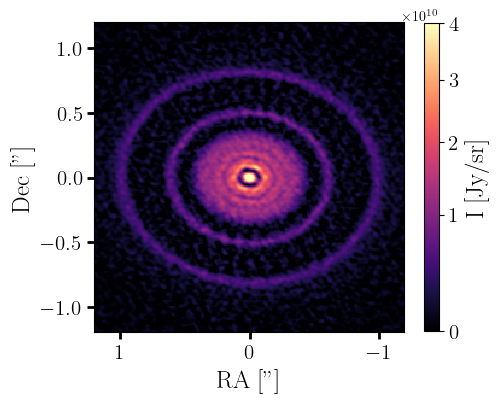

In [21]:
Plot_.intensity(gamma=0.7, zoom=3, vmax = 4e10, title="", fig_size=5, 
tick_label_size = 15, label_size = 18, title_size = 18)

### Open fits file
Of image regridded in CASA with imregrid, the same image from where we got the CLEAN model uvtable.

In [22]:
from astropy.io import fits
dir_  = "../../data/.image_fits/"
disk = 'CLEAN_AS209_dotimage_fov7p18_imsize772.fits' # this is the model regridded!

fits_name = dir_ + disk

In [23]:
hdul = fits.open(fits_name)

In [24]:
import matplotlib.colors as colors

### CLEAN model imregridded

In [25]:
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS

In [26]:
hdr = hdul[0].header
data = hdul[0].data 

In [27]:
# beam
bmaj = hdr.get('BMAJ') # degrees
bmaj_as = bmaj * 3600 # arcseconds
bmin = hdr.get('BMIN')
bmin_as = bmin * 3600 # arcseconds
bpa = hdr.get('BPA')

In [28]:
w = WCS(hdr)

In [29]:
data_squeezed = np.squeeze(data)   # (3000,3000) si los ejes 1 desaparecen
print("shape original:", data.shape, "-> squeezed:", data_squeezed.shape)

shape original: (1, 1, 772, 772) -> squeezed: (772, 772)


In [30]:
data = data_squeezed

In [31]:
if data.ndim == 3:
    # asumo (nz, ny, nx)
    nz, ny, nx = data.shape
    if channel_index is None:
        # elige el canal central por defecto
        ci = nz // 2
    else:
        ci = int(channel_index)
    img = data[ci, :, :].copy()
    # build a WCS for the 2D plane (drop the spectral axis)
    w2 = w.celestial  # WCS restringido a ejes celestes (RA/Dec)
else:
    ny, nx = data.shape
    img = data.copy()
    w2 = w.celestial

In [32]:
# pixel coordinates
x = np.arange(nx)
y = np.arange(ny)
xx, yy = np.meshgrid(x, y)

# wcs expects pixel coords in 1-based -> use wcs_pix2world with origin=0
ra_deg, dec_deg = w2.wcs_pix2world(xx, yy, 0)  # devuelve en grados

# reference coordinate (CRVAL)
crval_ra = w2.wcs.crval[0]
crval_dec = w2.wcs.crval[1]
refcoord = SkyCoord(crval_ra*u.deg, crval_dec*u.deg)

# compute offsets in arcsec from reference coordinate
coords = SkyCoord(ra_deg*u.deg, dec_deg*u.deg)
lon_off, lat_off = coords.spherical_offsets_to(refcoord)
# convertir a arcsec, y poner el eje x como RA offset (positivo hacia el Este)
ra_off_arcsec = -lon_off.to(u.arcsec).value
dec_off_arcsec = lat_off.to(u.arcsec).value

# extent of the image in arcsec (for imshow)
xmin = ra_off_arcsec.min()
xmax = ra_off_arcsec.max()
ymin = dec_off_arcsec.min()
ymax = dec_off_arcsec.max()

# we need to flip the y axis to match the imshow convention
img = np.flipud(img)



In [33]:
cellsize_clean = np.abs(ra_off_arcsec[0][1]-ra_off_arcsec[0][0])

In [34]:
pixel_scale_x_as = cellsize_clean
pixel_scale_y_as = cellsize_clean

bmaj_pix = bmaj_as/pixel_scale_x_as
bmin_pix = bmin_as/pixel_scale_y_as
angle_display = 90.0 - bpa 

In [35]:
rout*2 / imsize  

0.0031088082901554403

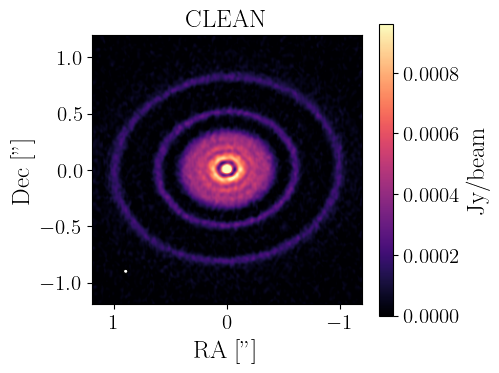

In [36]:
import matplotlib.patches as patches
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(5,5))
norm = colors.PowerNorm(gamma=1, vmin=0, vmax = img.max()/2)
ax = plt.gca()

im = ax.imshow(
    img,
    extent=[xmax, xmin, ymax, ymin],
    aspect='equal',
    cmap='magma',
    norm=norm,
)


ax.set_xlabel('RA ["]', size=18)
ax.set_ylabel('Dec ["]', size=18)
ax.set_xlim(xmax/3, xmin/3)
ax.set_ylim(ymax/3, ymin/3)
ax.set_title(r'CLEAN', size=18)
plt.tick_params(axis='both', labelsize=15)

cbar = plt.colorbar(im, ax=ax, shrink=0.65)
cbar.set_label( hdr.get('BUNIT'), size=18)
cbar.ax.tick_params(labelsize=15)
cbar.update_ticks()
ax.grid(False)

xloc = xmin + 0.5 * (xmax - xmin)
yloc = ymin + 0.5 * (ymax - ymin)


beam = patches.Ellipse(
    (0.9, -0.9), 
    width=bmaj_as, 
    height=bmin_as, 
    angle=angle_display, 
    facecolor='white', 
    edgecolor='black', 
    linewidth=0.8, 
    zorder=5
)

ax.add_patch(beam)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [37]:
# arcsecs per pixel
ra_off_arcsec[0][1] -ra_off_arcsec[0][0]

np.float64(-0.00930055965918486)

### Convolution2D

In [38]:
fwhm_clean_geom = np.sqrt(bmaj_as * bmin_as)
fwhm_clean_geom

np.float64(0.03708447619153958)

In [39]:
FWHM_frank2d = 22e-3 # arcsec
FWHM_frank1d = 15.2e-3 # arcsec

fwhm_frank1d = np.sqrt(fwhm_clean_geom**2 - FWHM_frank1d**2)
fwhm_frank2d = np.sqrt(fwhm_clean_geom**2 - FWHM_frank2d**2)

In [40]:
pixel_scale_arcsec = (frank2d.x_grid[0][1] - frank2d.x_grid[0][0]) * rad_to_arcsec
cellsize_f2d = pixel_scale_arcsec

In [41]:
clean_beam = {'bmaj': bmaj_as, 'bmin': bmin_as, 'beam_pa': bpa}
clean_area = clean_beam['bmaj']*clean_beam['bmin']*np.pi/4./np.log(2.)*(1/rad_to_arcsec)**2

In [42]:
# import f1d image
dir_f1d = "../../data/f1d/"

# let's open "f1d_AS209_N395_alpha1.05_wsmooth0.0001_rout1.9.pickle"
import pickle
f1d_file = dir_f1d + "f1d_AS209_N386_alpha1.2_wsmooth0.01_rout3.5999999999999996.pickle"
with open(f1d_file, 'rb') as handle:
    frank1d = pickle.load(handle)

In [43]:
f1d_cellsize = frank1d.r[1]- frank1d.r[0]
f1d_cellsize

np.float64(0.009230293898760749)

In [44]:
from scipy.interpolate import interp1d


def sweep_profile(r, I, project=False, phase_shift=False, geom=None, axis=0,
                  xmax=None, ymax=None, dr=None):
    r"""
    Sweep a 1D radial brightness profile over :math:`2 \pi` to yield a 2D
    brightness distribution. Optionally project this sweep by a supplied
    geometry.

    Parameters
    ----------
    r : array
        Radial coordinates at which the 1D brightness profile is defined
    I : array
        Brightness values at r
    project : bool, default = False
        Whether to project the swept profile by the supplied geom
    phase_shift : bool, default = False
        Whether to phase shift the projected profile by the supplied geom.
        If False, the source will be centered in the image
    geom : SourceGeometry object, default=None
        Fitted geometry (see frank.geometry.SourceGeometry). Here we use
        geom.inc [deg], geom.PA [deg], geom.dRA [arcsec], geom.dDec [arcsec] if
        project=True
    axis : int, default = 0
        Axis over which to interpolate the 1D profile
    xmax, ymax : float, optional, default = None
        Value setting the x- and y-bounds of the image (same units as r). The
        positive and negative bounds are both set to this value (modulo sign).
        If not provided, these will be set to r.max()
    dr : float, optional, default = None
        Pixel size (same units as r). If not provided, it will be set at the
        same spatial scale as r

    Returns
    -------
    I2D : array, shape = (len(r), len(r))
        2D brightness distribution (projected if project=True)
    xmax : float
        Maximum x-value of the 2D grid
    ymax : float
        Maximum y-value of the 2D grid

    Notes
    -----
    Sign convention: a negative geom.dRA shifts the source to the right
    in the image

    """
    if project:
        inc, pa = geom.inc, geom.PA
        inc *= deg_to_rad
        pa *= deg_to_rad

        cos_i = np.cos(inc)
        cos_pa, sin_pa = np.cos(pa), np.sin(pa)

    if xmax is None:
        xmax = r.max()
    if ymax is None:
        ymax = r.max()

    if dr is None:
        dr = np.mean(np.diff(r))
    
    N = 2*int(xmax/dr)
    x = np.linspace(-xmax, xmax, N)
    y = np.linspace(-ymax, ymax, N)

    if phase_shift:
        xi, yi = np.meshgrid(x + geom.dRA, y - geom.dDec)
    else:
        xi, yi = np.meshgrid(x, y)

    if project:
        xp  = xi * cos_pa + yi * sin_pa
        yp  = -xi * sin_pa + yi * cos_pa
        xp /= cos_i
        r1D = np.hypot(xp, yp)
    else:
        r1D = np.hypot(xi, yi)

    im_shape = r1D.shape + I.shape
    print(im_shape)

    interp = interp1d(r, I, bounds_error=False, fill_value=0., axis=axis)
    I2D = interp(r1D.ravel()).reshape(N, N)

    return I2D, xmax, ymax

In [45]:
#from frank.utilities import sweep_profile
from frank.geometry import SourceGeometry
geom_f1d = SourceGeometry(inc, pa, dra, ddec) 
I_f1d_2d, r_max, r_min = sweep_profile(frank1d.r, frank1d.mean, project= True, phase_shift = False, xmax = Rmax, ymax = Rmax, geom = geom_f1d, dr = frank2d.cellsize )

(772, 772, 386)


In [46]:
I_f1d_2d = np.flipud(I_f1d_2d)

In [47]:
import scipy.ndimage as ndimage
from scipy.ndimage import gaussian_filter

sigma_pixels_f2d = fwhm_frank2d / (2.35482 * pixel_scale_arcsec)
I_frank2d_convolved_2d = gaussian_filter(frank2d.intensity_model, sigma=sigma_pixels_f2d)
I_frank2d_convolved_2d *= clean_area 

sigma_pixels_f1d = fwhm_frank1d / (2.35482 * pixel_scale_arcsec)
I_f1d_convolved_2d = gaussian_filter(I_f1d_2d, sigma=sigma_pixels_f1d)    
I_f1d_convolved_2d *= clean_area


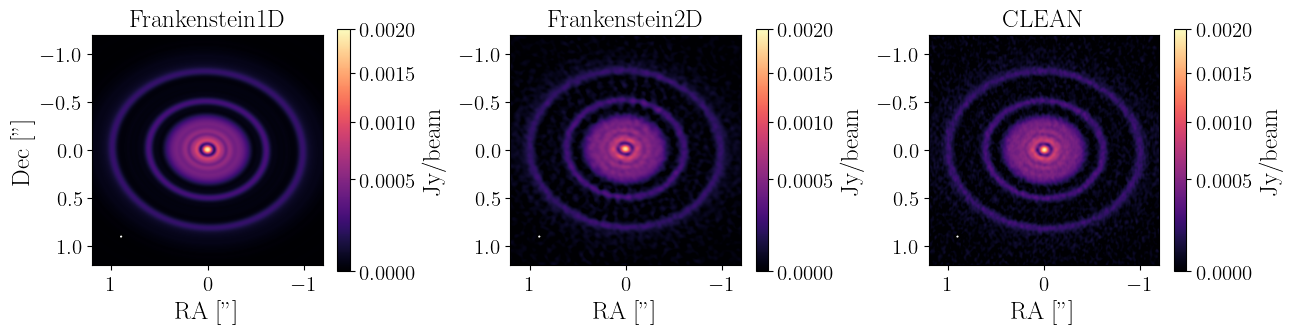

In [48]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.colors as colors
import numpy as np


lista_imagenes = [I_f1d_convolved_2d, I_frank2d_convolved_2d, img]
titulos = ["Frankenstein1D", "Frankenstein2D", "CLEAN"]
# -----------------------------------------

hdr = {'BUNIT': 'Jy/beam'}

# Crear figura
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(13, 4))

# Bucle conjunto sobre los ejes y las imágenes
# 'zip' empareja el ax[0] con img1, ax[1] con img2, etc.
for i, (ax, img_data) in enumerate(zip(axes, lista_imagenes)):
    
    # Calcular normalización específica para ESTA imagen
    norm = colors.PowerNorm(gamma=0.7, vmin=0, vmax=0.002)
    
    im = ax.imshow(
        img_data,
        extent=[-Rmax, Rmax, -Rmax, Rmax],
        aspect='equal',
        cmap='magma',
        norm=norm,
    )

    ax.set_xlabel('RA ["]', size=18)
    if i == 0:
        ax.set_ylabel('Dec ["]', size=18)
    
    ax.set_xlim(Rmax/3, -Rmax/3)
    ax.set_ylim(-Rmax/3, Rmax/3)
    ax.set_title(titulos[i], size=18) # Usar título correspondiente
    ax.tick_params(axis='both', labelsize=15)

    cbar = plt.colorbar(im, ax=ax, shrink=0.7)
    cbar.set_label(hdr.get('BUNIT'), size=18)
    cbar.ax.tick_params(labelsize=15)
    cbar.update_ticks()
    ax.grid(False)


    loc = (0.9, 0.9)

    beam = patches.Ellipse(
            loc, 
            width=bmaj_as, 
            height=bmin_as, 
            angle=angle_display, 
            facecolor='white', 
            edgecolor='black', 
            linewidth=1, 
            zorder=5)
        
    ax.add_patch(beam)

    ax.invert_yaxis()

plt.tight_layout()
plt.show()

#### Difference

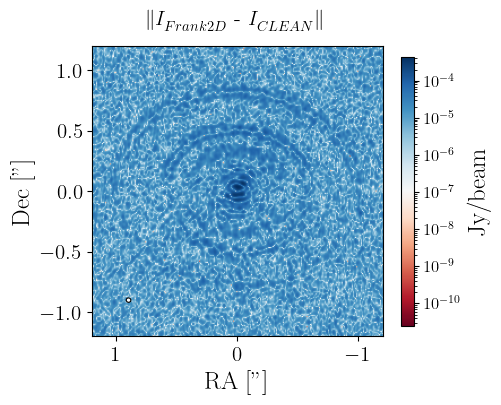

In [49]:
diff = np.abs(I_frank2d_convolved_2d - img)

plt.figure(figsize=(5,5))
#norm = colors.PowerNorm(gamma=0.7, vmin=1e-2, vmax = 1e10)
norm = colors.LogNorm()

ax = plt.gca()

im = ax.imshow(
    diff,
    extent=[Rmax, -Rmax, -Rmax, Rmax],
    aspect='equal',
    cmap='RdBu',
    norm=norm,
)

ax.set_xlabel('RA ["]', size=18)
ax.set_ylabel('Dec ["]', size=18)
ax.set_xlim(Rmax/3, -Rmax/3)
ax.set_ylim(Rmax/3, -Rmax/3)
ax.set_title(r'$\|I_{Frank2D}^{}$ - $I_{CLEAN}^{}\|$', size=15, pad=15)
ax.tick_params(axis='both', labelsize=15)


cbar = plt.colorbar(im, ax=ax, shrink=0.6)
cbar.set_label('Jy/beam', size=18)
cbar.ax.tick_params(labelsize=12)
cbar.update_ticks()
ax.grid(False)


beam = patches.Ellipse(
    (0.9, -0.9), 
    width=bmaj_as, 
    height=bmin_as, 
    angle=angle_display, 
    facecolor='white', 
    edgecolor='black', 
    linewidth=0.8, 
    zorder=5
)

ax.add_patch(beam)

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

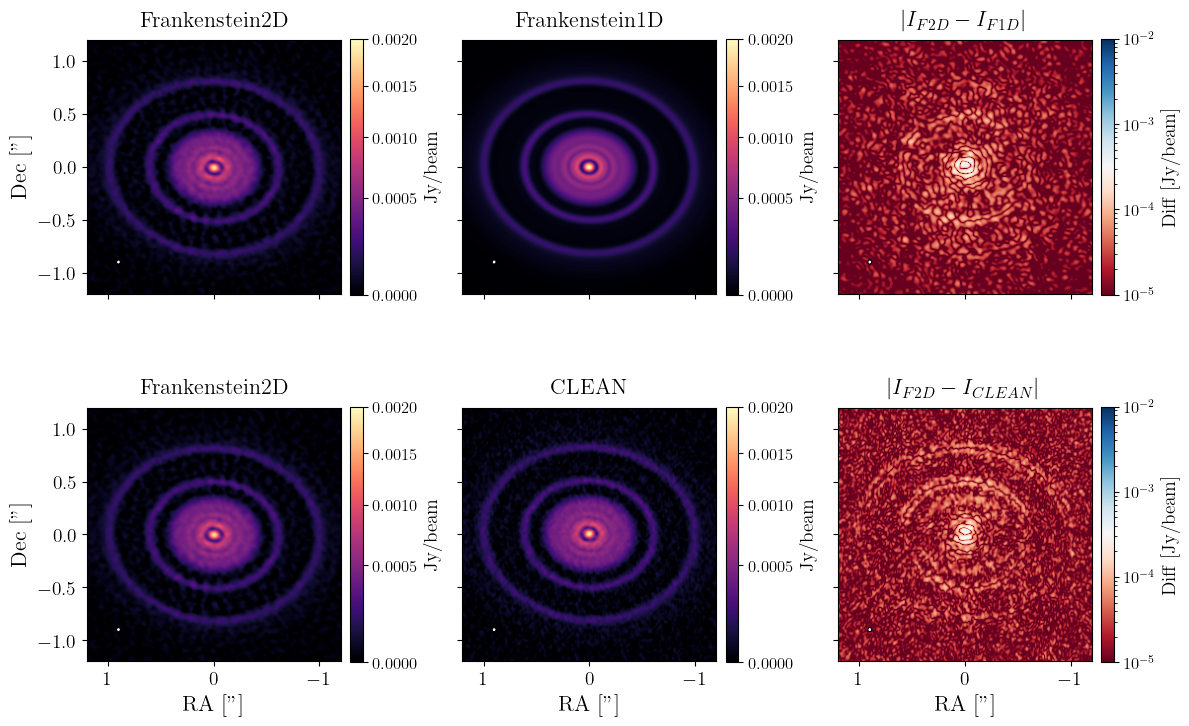

In [50]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.colors as colors
import numpy as np

# --- 1. PREPARACIÓN DE DATOS Y RESIDUALES ---

# Fila 1: Comparación entre Modelos (Frank2D vs Frank1D)
# Calculamos el residual absoluto entre ellos
diff_models = np.abs(I_frank2d_convolved_2d - I_f1d_convolved_2d)

# Fila 2: Comparación con la Verdad/Imagen (Frank2D vs CLEAN)
# Calculamos el residual absoluto con CLEAN
diff_clean = np.abs(I_frank2d_convolved_2d - img)

# Definimos una estructura de datos para iterar fácilmente
# Formato: [Imagen, Título, Es_Residual]
rows_data = [
    # ROW 1
    [
        (I_frank2d_convolved_2d, "Frankenstein2D", False),
        (I_f1d_convolved_2d,     "Frankenstein1D", False),
        (diff_models,            r"$|I_{F2D} - I_{F1D}|$", True)
    ],
    # ROW 2
    [
        (I_frank2d_convolved_2d, "Frankenstein2D", False),
        (img,                    "CLEAN",          False),
        (diff_clean,             r"$|I_{F2D} - I_{CLEAN}|$", True)
    ]
]

# Configuración de límites y escalas
limit_val = Rmax / 3  # El zoom que pediste
vmax_img = 0.002      # Valor fijo que tenías en tu código original
vmin_res = 1e-5       # Ajusta según el piso de ruido de tu residual
vmax_res = 1e-2       # Ajusta según el pico de tu residual

# --- 2. GENERACIÓN DE LA FIGURA ---

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12, 8), sharex=True, sharey=True)

# Ajuste fino del espacio entre subplots
plt.subplots_adjust(wspace=0.1, hspace=0.15)

# Iteramos sobre las filas (i) y columnas (j)
for i in range(2):
    for j in range(3):
        ax = axes[i, j]
        data, title, is_residual = rows_data[i][j]
        
        # A) Configuración de Normalización y Colormap
        if is_residual:
            # Residuales: Escala Logarítmica y colormap de error
            norm = colors.LogNorm(vmin=vmin_res, vmax=vmax_res)
            # Usamos 'inferno' o 'magma' porque diff es absoluto (todo positivo). 
            # Si usas 'RdBu' con abs(), solo verás la mitad roja.
            cmap = 'RdBu' 
        else:
            # Imágenes: PowerNorm (Gamma)
            norm = colors.PowerNorm(gamma=0.7, vmin=0, vmax=vmax_img)
            cmap = 'magma'

        # B) Plot
        im = ax.imshow(
            data,
            extent=[Rmax, -Rmax, Rmax, -Rmax], # RA invertido por convención (- a izq) en display
            origin='lower',
            cmap=cmap,
            norm=norm,
        )

        # C) Estética de Ejes
        ax.set_xlim(limit_val, -limit_val) # Invertido para RA (Positivo a la izquierda)
        ax.set_ylim(-limit_val, limit_val)
        
        ax.set_title(title, size=16, pad=10)
        ax.tick_params(axis='both', labelsize=14)
        ax.grid(False)

        # Etiquetas solo en los bordes externos
        if i == 1: # Solo fila inferior
            ax.set_xlabel('RA ["]', size=16)
        if j == 0: # Solo columna izquierda
            ax.set_ylabel('Dec ["]', size=16)

        # D) Colorbar individual
        cbar = plt.colorbar(im, ax=ax, shrink=0.7, pad=0.03)
        cbar.ax.tick_params(labelsize=12)
        
        if is_residual:
            cbar.set_label('Diff [Jy/beam]', size=14)
        elif j == 2: # Poner label solo al final de la fila de imágenes si prefieres
             cbar.set_label('Jy/beam', size=14)
        else:
             cbar.set_label('Jy/beam', size=14)

        # E) Beam Patch (Posición dinámica basada en el límite del zoom)
        # Calculamos posición para la esquina inferior izquierda dentro del zoom
        x_beam = limit_val * 0.75   # Un poco menos que el borde izquierdo
        y_beam = -limit_val * 0.75  # Un poco más arriba del borde inferior
        
        beam = patches.Ellipse(
            (x_beam, y_beam), 
            width=bmaj_as, 
            height=bmin_as, 
            angle=90+angle_display, # Ajuste típico de ángulo para matplotlib
            facecolor='white', 
            edgecolor='black', 
            linewidth=0.8, 
            zorder=10
        )
        ax.add_patch(beam)

        # Si en tu código original invertías Y manualmente, descomenta esto.
        # Normalmente con origin='lower' no hace falta, salvo que tus datos estén flippeados.
        #ax.invert_yaxis()

plt.tight_layout()
plt.show()

## 1D Profile

In [51]:
f2d = frank2d
geom = geom_f2d
inc, pa, dra, ddec = geom.inc, geom.pa, geom.dra, geom.ddec

In [52]:
from gofish import imagecube
cube_1mm = imagecube(fits_name)
x_clean, y_clean, dy_clean = cube_1mm.radial_profile(inc= inc, PA=pa, x0=dra, y0=ddec)

	 Reverting to standard azimuthal averaging; will ignore `unit` argument.


In [53]:
beam_frank2d = {'bmaj': FWHM_frank2d, 'bmin': FWHM_frank2d, 'beam_pa': 0}
beam_clean = {'bmaj': bmaj_as, 'bmin': bmin_as, 'beam_pa': bpa}
final_beam_f2d = calculate_resolution2( beam_clean, beam_frank2d)

In [54]:
fits_image = fits.open(fits_name)
header = fits_image[0].header
bmaj_deg = float(header["BMAJ"])
bmin_deg = float(header["BMIN"])
bmaj_as = bmaj_deg * 3600.0
bmin_as = bmin_deg * 3600.0
bpa_deg = header['BPA']

clean_beam = {'bmaj': bmaj_as, 'bmin': bmin_as, 'beam_pa': bpa_deg}
clean_area = clean_beam['bmaj']*clean_beam['bmin']*np.pi/4./np.log(2.)*(1/rad_to_arcsec)**2
area = clean_area
print(f"Clean beam: {bmaj_as} x {bmin_as} arcsec")

beam_for_f2d = calculate_resolution(clean_beam, FWHM_frank2d)
beam_for_f2d = final_beam_f2d

Clean beam: 0.038338888436568 x 0.035871107131242 arcsec
-> Final beam to convolve with: 0.03139857268334991 x 0.02833260183641878 arcsec


In [55]:
# f2d model
u_model = f2d.u_grid
v_model = f2d.v_grid
vis_model = f2d.visibility_model

u_model_1d = f2d.u
v_model_1d = f2d.v

x_model = f2d.x_grid * rad_to_arcsec
y_model = f2d.y_grid * rad_to_arcsec

x_model_1d = f2d.x * rad_to_arcsec
y_model_1d = f2d.y * rad_to_arcsec

        
# phase shift
vis = geom.apply_phase_shift(-u_model, -v_model, vis_model) # the East of North convention.
I = f2d.transform(vis).real

# deproject
x_model, y_model = geom.deproject_xy(x_model, y_model)
x_model_1d_d, y_model_1d_d = geom.deproject_xy(x_model_1d, y_model_1d)

# collocation points for the plot.
r = np.unique(np.hypot(x_model_1d_d, y_model_1d_d))
bins = N
r = np.linspace(r.min(), r.max(), bins)
edges_ = edges(r)


r_model_1d, I_model_1d = get_profile(x_model, y_model, I, bins = edges_)
I_model_1d = np.nan_to_num(I_model_1d, nan=0)

In [56]:
from frank.utilities import convolve_profile
I_model_1d_convolved = convolve_profile(r_model_1d, I_model_1d, inc, pa, beam_for_f2d)
I_model_1d_convolved *= area # Jy/beam

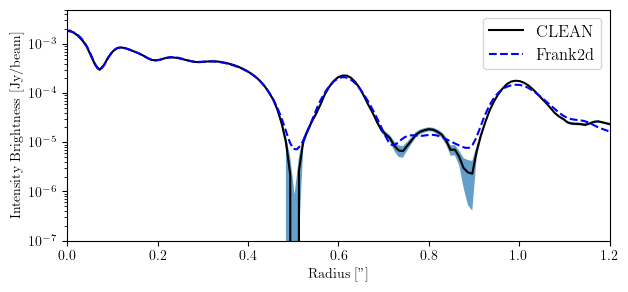

In [57]:
plt.figure(figsize=(7,3))
#  CLEAN --------------------------------------------------------------------
plt.plot(x_clean, y_clean, "black", label = "CLEAN")
plt.fill_between(x_clean, y_clean-dy_clean, y_clean+dy_clean, alpha=0.7)
# frank2D -------------------------------------------------------------------
plt.plot(r_model_1d, I_model_1d_convolved, color = 'blue',ls ='--', label = r'Frank2d')

plt.ylabel(r'Intensity Brightness [Jy/beam]', size=10)
plt.xlabel('Radius ["]', size=10)
plt.legend(fontsize=12)
plt.yscale('log')
plt.xlim(0, Rmax/3)
plt.ylim(1e-7, 0.5e-2)
plt.show()

In [58]:
f1d = frank1d

In [59]:
beam_frank1d = {'bmaj': FWHM_frank1d, 'bmin': FWHM_frank1d, 'beam_pa': 0}
final_beam_f1d = calculate_resolution2( clean_beam, beam_frank1d)

In [60]:
r_f1d = f1d.r
I_f1d = f1d.mean
I_f1d_convolved = convolve_profile(r_f1d[0:], I_f1d[0:], inc, pa, final_beam_f1d)
I_f1d_convolved *= clean_area # Jy/beam

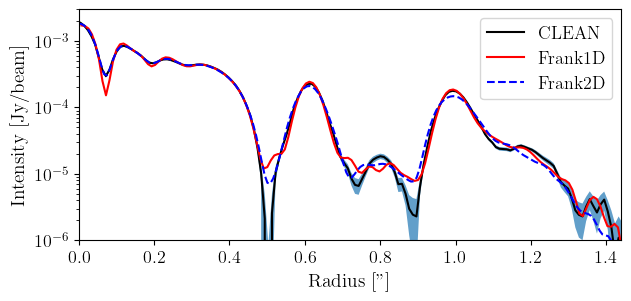

In [61]:
plt.figure(figsize=(7,3))
#  CLEAN --------------------------------------------------------------------
plt.plot(x_clean, y_clean, "black", label = "CLEAN")
plt.fill_between(x_clean, y_clean-dy_clean, y_clean+dy_clean, alpha=0.7)
# frank1D -------------------------------------------------------------------
plt.plot(r_f1d, I_f1d_convolved, color = 'red',ls ='-', label = r'Frank1D')
# frank2D -------------------------------------------------------------------
plt.plot(r_model_1d, I_model_1d_convolved, color = 'blue',ls ='--', label = r'Frank2D')

plt.ylabel(r'Intensity [Jy/beam]', size=14)
plt.xlabel('Radius ["]', size=14)
plt.legend(fontsize=13)
plt.tick_params(axis='both', which='both', labelsize=13)
plt.yscale('log')
plt.title(f'')
plt.xlim(0, Rmax/2.5)
plt.ylim(1e-6, 3e-3)
plt.show()

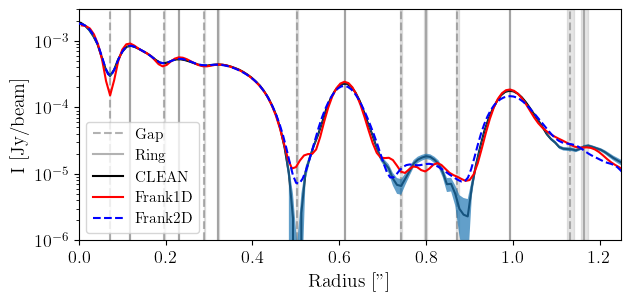

In [62]:
import matplotlib.pyplot as plt
import numpy as np

# ... (tus definiciones de datos previas: x_clean, r_f1d, etc.) ...

plt.figure(figsize=(7,3))

# --- DEFINICIÓN DE DATOS (Posición, Error) en mas ---
# Extraídos de la columna 5 de la tabla
# Tuplas: (posición_mas, error_mas)

gaps_data = [
    (71.8, 0.8), 
    (197.0, 1.3), 
    (289.6, 1.6), 
    (503, 3), 
    (742.6, 3), 
    (872, 3), 
    (1132, 8)
]

rings_data = [
    (117.6, 1.1), 
    (230, 2), 
    (320, 2), 
    (612.8, 1.3), 
    (799, 4), 
    (992.9, 1.3), 
    (1165, 8)
]

# --- DIBUJAR GAPS Y ANILLOS CON INCERTIDUMBRE ---

# 1. GAPS (Lineas discontinuas)
for i, (pos, err) in enumerate(gaps_data):
    # Conversión a arcsec
    pos_sec = pos / 1000.0
    err_sec = err / 1000.0
    
    # Etiqueta solo para el primero para no ensuciar la leyenda
    label = 'Gap' if i == 0 else None
    
    # Linea central
    plt.axvline(x=pos_sec, color='gray', linestyle='--', alpha=0.6, zorder=0, label=label)
    # Sombreado de error (span)
    plt.axvspan(pos_sec - err_sec, pos_sec + err_sec, color='gray', alpha=0.2, zorder=0)

# 2. ANILLOS (Lineas continuas)
for i, (pos, err) in enumerate(rings_data):
    # Conversión a arcsec
    pos_sec = pos / 1000.0
    err_sec = err / 1000.0
    
    # Etiqueta solo para el primero
    label = 'Ring' if i == 0 else None
    
    # Linea central
    plt.axvline(x=pos_sec, color='gray', linestyle='-', alpha=0.6, zorder=0, label=label)
    # Sombreado de error (span)
    plt.axvspan(pos_sec - err_sec, pos_sec + err_sec, color='gray', alpha=0.2, zorder=0)


# --- PLOTEO DE DATOS --- 
#  CLEAN 
plt.plot(x_clean, y_clean, "black", label = "CLEAN", zorder=2)
plt.fill_between(x_clean, y_clean-dy_clean, y_clean+dy_clean, alpha=0.7, zorder=2)

# frank1D 
plt.plot(r_f1d, I_f1d_convolved, color = 'red', ls ='-', label = r'Frank1D', zorder=3)

# frank2D 
plt.plot(r_model_1d, I_model_1d_convolved, color = 'blue', ls ='--', label = r'Frank2D', zorder=3)

# --- CONFIGURACIÓN FINAL ---
plt.ylabel(r'I [Jy/beam]', size=14)
plt.xlabel('Radius ["]', size=14)

# Ajusté el loc para que no tape los datos, 'upper right' suele ser bueno en estos perfiles
plt.legend(fontsize=11, loc='best', frameon=True) 

plt.tick_params(axis='both', which='both', labelsize=13)
plt.yscale('log')

# Limites
plt.xlim(0, 1.25) # Ajustado aprox según tu último dato (1165mas) para que se vea todo
plt.ylim(1e-6, 3e-3)

plt.show()

In [69]:
import numpy as np

# 1. Definir el grid radial común para la evaluación
# Según el texto, evaluaremos entre 0.0" y 1.1" (donde está la estructura principal)
r_min = 0.0
r_max = rout

# Creamos un eje X común con alta resolución (ej. 1000 puntos)
r_common = np.linspace(r_min, r_max, 1000)

# 2. Interpolar los tres perfiles de intensidad a este eje X común
# Usamos np.interp(x_nuevo, x_original, y_original)

# Benchmark (El "Gold Standard")
I_f1d_interp = np.interp(r_common, r_f1d, I_f1d_convolved)

# Los modelos a evaluar
I_clean_interp = np.interp(r_common, x_clean, y_clean)
I_f2d_interp = np.interp(r_common, r_model_1d, I_model_1d_convolved)

# 3. Definir la función del NRMSE (Norma L2 de la diferencia / Norma L2 de la referencia)
def calculate_nrmse(I_model, I_benchmark):
    residual_norm = np.linalg.norm(I_model - I_benchmark)
    benchmark_norm = np.linalg.norm(I_benchmark)
    return residual_norm / benchmark_norm

# 4. Calcular e imprimir los resultados
nrmse_clean = calculate_nrmse(I_clean_interp, I_f1d_interp)
nrmse_f2d = calculate_nrmse(I_f2d_interp, I_f1d_interp)

print("=== Resultados NRMSE de Perfiles 1D ===")
print(f"CLEAN vs Frank1D:   {nrmse_clean:.4f}")
print(f"Frank2D vs Frank1D: {nrmse_f2d:.4f}")

=== Resultados NRMSE de Perfiles 1D ===
CLEAN vs Frank1D:   0.0732
Frank2D vs Frank1D: 0.0658


In [68]:
rout

1.2